# Notebook 6 — Model Evaluation and Feature Importance
## Telecom Customer Retention Intelligence Platform

**Objective:** Deep evaluate the selected XGBoost model,
interpret feature importance, and translate findings into
actionable business recommendations.

**Input:** models/best_model.pkl  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load saved model, scaler, and feature names
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Load featured dataset
df = pd.read_csv('../data/processed/telco_churn_featured.csv')

print(f"Model loaded: {type(model).__name__}")
print(f"Features expected: {len(feature_names)}")
print(f"Dataset shape: {df.shape}")

Model loaded: XGBClassifier
Features expected: 38
Dataset shape: (7043, 39)


## 2. Rebuild Train Test Split
Must use identical split as Notebook 5 — same random_state=42.

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'ServiceCount']

X_train_smote[numerical_cols] = scaler.fit_transform(
    X_train_smote[numerical_cols]
)
X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Data rebuilt and predictions generated")
print(f"Test set size: {X_test.shape[0]:,}")

Data rebuilt and predictions generated
Test set size: 1,409


## 3. Full Classification Report

In [4]:
print("XGBoost — Full Classification Report")
print("=" * 50)
print(classification_report(
    y_test, y_pred,
    target_names=['Retained', 'Churned']
))

XGBoost — Full Classification Report
              precision    recall  f1-score   support

    Retained       0.88      0.75      0.81      1035
     Churned       0.51      0.73      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.74      0.76      1409



## 4. Confusion Matrix — Detailed View

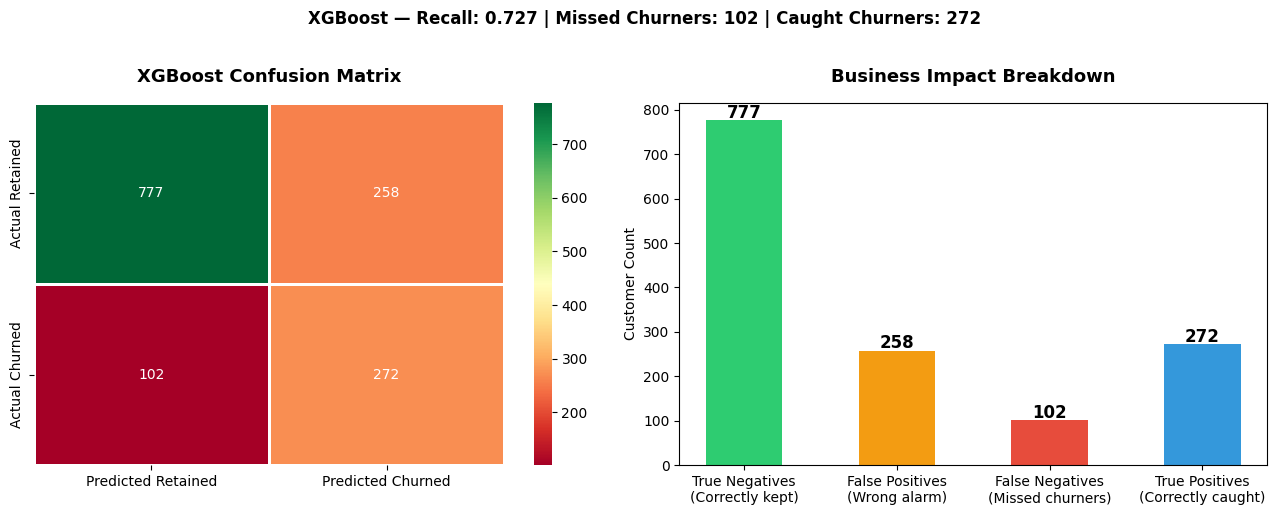


Business Summary:
  Churners correctly flagged: 272 (72.7% of all churners)
  Churners missed:            102 (27.3% of all churners)
  False alarms generated:     258
  Estimated monthly revenue
  at risk from missed churners: $7,548


In [5]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — heatmap
sns.heatmap(cm, annot=True, fmt='d',
            cmap='RdYlGn', ax=axes[0],
            linewidths=1,
            xticklabels=['Predicted Retained',
                         'Predicted Churned'],
            yticklabels=['Actual Retained',
                         'Actual Churned'])
axes[0].set_title('XGBoost Confusion Matrix',
                   fontsize=13, fontweight='bold', pad=15)

# Right — business interpretation
categories = ['True Negatives\n(Correctly kept)',
              'False Positives\n(Wrong alarm)',
              'False Negatives\n(Missed churners)',
              'True Positives\n(Correctly caught)']
values = [tn, fp, fn, tp]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']

bars = axes[1].bar(categories, values,
                   color=colors, edgecolor='none',
                   width=0.5)

for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(val), ha='center',
        fontsize=12, fontweight='bold'
    )

axes[1].set_title('Business Impact Breakdown',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Customer Count')

plt.suptitle(
    f'XGBoost — Recall: {tp/(tp+fn):.3f} | '
    f'Missed Churners: {fn} | '
    f'Caught Churners: {tp}',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_detailed.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBusiness Summary:")
print(f"  Churners correctly flagged: {tp} "
      f"({tp/(tp+fn)*100:.1f}% of all churners)")
print(f"  Churners missed:            {fn} "
      f"({fn/(tp+fn)*100:.1f}% of all churners)")
print(f"  False alarms generated:     {fp}")
print(f"  Estimated monthly revenue")
print(f"  at risk from missed churners: "
      f"${fn * 74:,.0f}")

## 5. ROC Curve — XGBoost Deep Dive

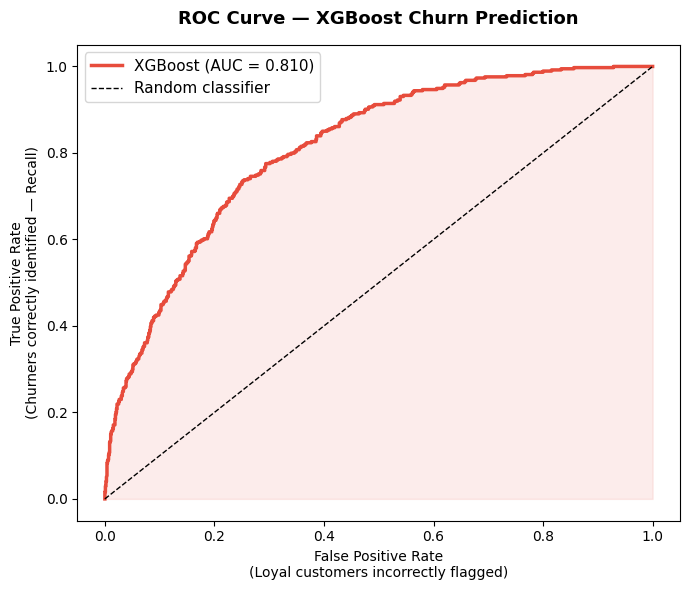

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#e74c3c',
        linewidth=2.5,
        label=f'XGBoost (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--',
        linewidth=1, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

ax.set_title('ROC Curve — XGBoost Churn Prediction',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate\n'
              '(Loyal customers incorrectly flagged)')
ax.set_ylabel('True Positive Rate\n'
              '(Churners correctly identified — Recall)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/roc_curve_xgboost.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance — What Drives Churn?
This is the most business-valuable output of the entire
ML phase. It answers: what actually causes customers to leave?

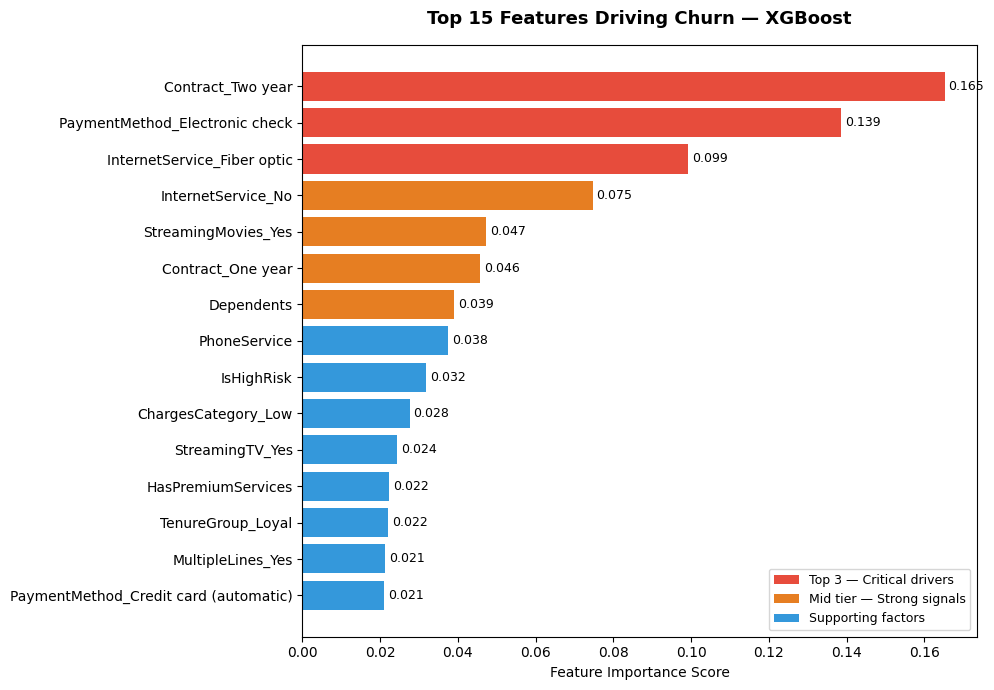


Top 10 Churn Drivers:
                       Feature  Importance
             Contract_Two year    0.165213
PaymentMethod_Electronic check    0.138621
   InternetService_Fiber optic    0.099274
            InternetService_No    0.074629
           StreamingMovies_Yes    0.047306
             Contract_One year    0.045692
                    Dependents    0.039044
                  PhoneService    0.037506
                    IsHighRisk    0.031722
           ChargesCategory_Low    0.027570


In [7]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if i < 3 else
          '#e67e22' if i < 7 else
          '#3498db'
          for i in range(len(importance_df))]

bars = ax.barh(importance_df['Feature'],
               importance_df['Importance'],
               color=colors, edgecolor='none')

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.invert_yaxis()
ax.set_title('Top 15 Features Driving Churn — XGBoost',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Top 3 — Critical drivers'),
    Patch(facecolor='#e67e22', label='Mid tier — Strong signals'),
    Patch(facecolor='#3498db', label='Supporting factors')
]
ax.legend(handles=legend_elements, fontsize=9,
          loc='lower right')

plt.tight_layout()
plt.savefig('../reports/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Churn Drivers:")
print(importance_df.head(10).to_string(index=False))

## 7. Churn Probability Distribution
Shows how confidently the model scores customers.

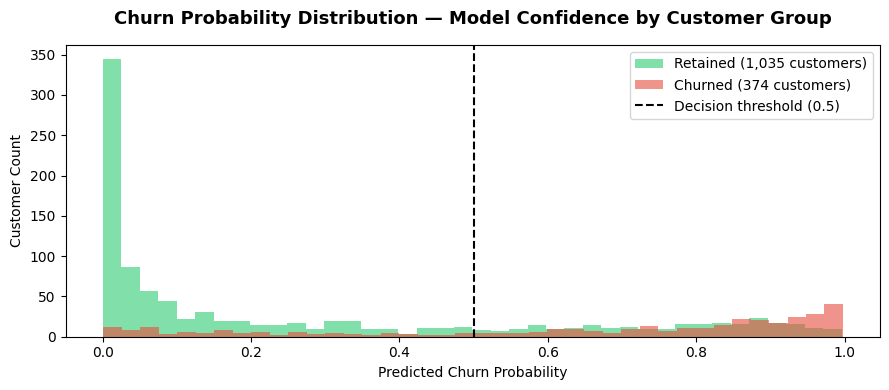

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

churned_probs = y_prob[y_test == 1]
retained_probs = y_prob[y_test == 0]

ax.hist(retained_probs, bins=40, alpha=0.6,
        color='#2ecc71', edgecolor='none',
        label=f'Retained ({len(retained_probs):,} customers)')
ax.hist(churned_probs, bins=40, alpha=0.6,
        color='#e74c3c', edgecolor='none',
        label=f'Churned ({len(churned_probs):,} customers)')

ax.axvline(x=0.5, color='black', linestyle='--',
           linewidth=1.5, label='Decision threshold (0.5)')

ax.set_title('Churn Probability Distribution — '
             'Model Confidence by Customer Group',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Customer Count')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../reports/probability_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()